In [1]:
!pip install --upgrade pgmpy --break-system-packages

In [2]:
#Esta librería no les sirve, es solo para el ejemplo 
pip install bnlearn --no-deps

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import bnlearn
from pgmpy.estimators import HillClimbSearch, ExhaustiveSearch
from pgmpy.estimators import BIC, BDeu, K2         
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator

/home/tomas/Escritorio/Tareas/tareas_ia/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [4]:
import pgmpy
print(pgmpy.__version__)

1.1.0


In [5]:
df = bnlearn.import_example('titanic')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
scoring_method = BIC(df)

hc = HillClimbSearch(df)
best_model_hc = hc.estimate(
    scoring_method=scoring_method,
    max_indegree=3,
    max_iter=500,      
    show_progress=True
)

[07-04-2026 17:53:03] [pgmpy] [INFO]  Datatype (N=numerical, C=Categorical Unordered,O=Categorical Ordered)inferred from data: 
 {'PassengerId': 'N', 'Survived': 'N', 'Pclass': 'N', 'Name': 'C', 'Sex': 'C', 'Age': 'N', 'SibSp': 'N', 'Parch': 'N', 'Ticket': 'C', 'Fare': 'N', 'Cabin': 'C', 'Embarked': 'C'}
[07-04-2026 17:53:03] [pgmpy] [INFO]  Datatype (N=numerical, C=Categorical Unordered,O=Categorical Ordered)inferred from data: 
 {'PassengerId': 'N', 'Survived': 'N', 'Pclass': 'N', 'Name': 'C', 'Sex': 'C', 'Age': 'N', 'SibSp': 'N', 'Parch': 'N', 'Ticket': 'C', 'Fare': 'N', 'Cabin': 'C', 'Embarked': 'C'}
[07-04-2026 17:53:03] [pgmpy] [INFO]  Datatype (N=numerical, C=Categorical Unordered,O=Categorical Ordered)inferred from data: 
 {'PassengerId': 'N', 'Survived': 'N', 'Pclass': 'N', 'Name': 'C', 'Sex': 'C', 'Age': 'N', 'SibSp': 'N', 'Parch': 'N', 'Ticket': 'C', 'Fare': 'N', 'Cabin': 'C', 'Embarked': 'C'}
[07-04-2026 17:53:03] [pgmpy] [WARNING] Variables: ['Survived', 'Pclass', 'SibSp',

  0%|          | 0/500 [00:00<?, ?it/s]

In [7]:
# Ver los arcos (relaciones) que aprendió la red
print("Relaciones encontradas:")
print(best_model_hc.edges())

Relaciones encontradas:
[('Survived', 'Sex'), ('Survived', 'Pclass'), ('Pclass', 'Embarked'), ('Sex', 'Parch'), ('Sex', 'Pclass'), ('Parch', 'SibSp'), ('Cabin', 'Survived')]


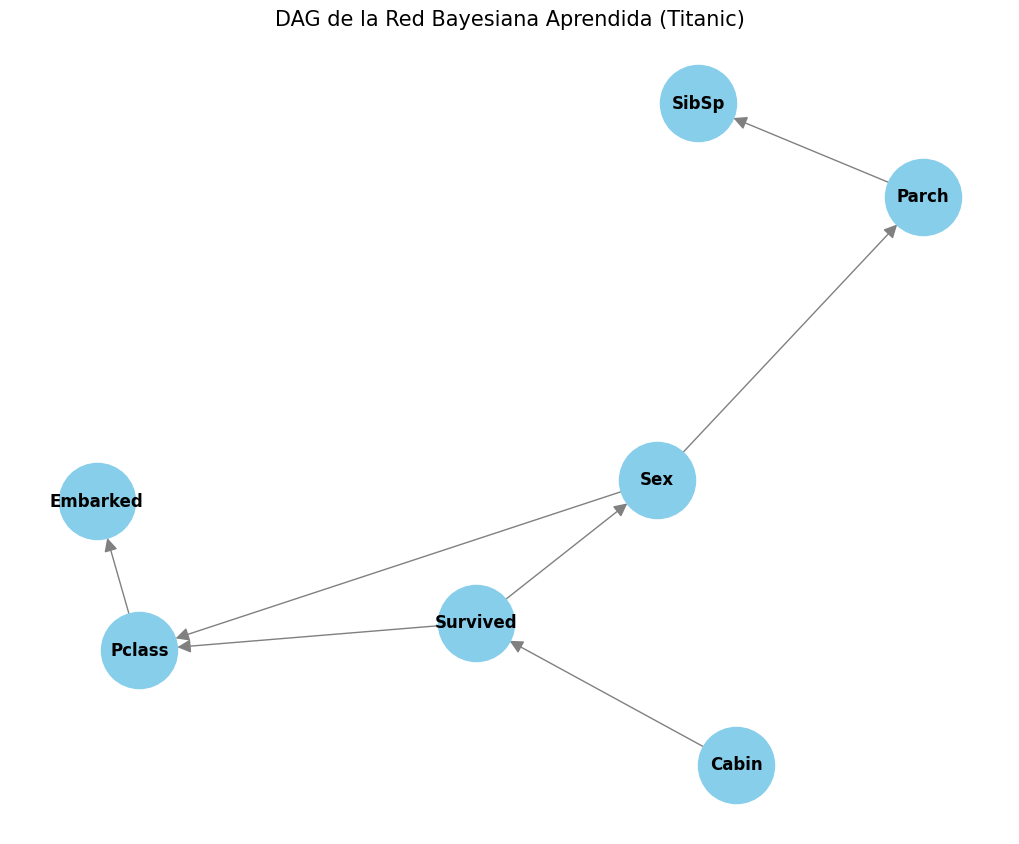

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear un objeto de grafo dirigido de NetworkX a partir de los resultados
dag = nx.DiGraph(best_model_hc.edges())

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(dag, seed=42) # Posiciona los nodos de forma estética

# Dibujar los nodos, etiquetas y flechas
nx.draw(dag, pos, with_labels=True, node_size=3000, node_color="skyblue", 
        font_size=12, font_weight="bold", arrowsize=20, edge_color="gray")

plt.title("DAG de la Red Bayesiana Aprendida (Titanic)", size=15)
plt.show()

In [9]:
from pgmpy.models import DiscreteBayesianNetwork
# 1. Definir el modelo final usando los arcos que aprendiste antes
# 'best_model_hc' es el objeto que resultó del HillClimbSearch
model = DiscreteBayesianNetwork(best_model_hc.edges())

# 2. Aprender los parámetros (las tablas de probabilidad)
# Usamos el DataFrame 'df' que ya tiene los datos discretizados
model.fit(df, estimator=MaximumLikelihoodEstimator)

# 3. Verificar que el modelo sea consistente
print(f"¿El modelo es válido?: {model.check_model()}")

[07-04-2026 17:54:06] [pgmpy] [INFO]  Datatype (N=numerical, C=Categorical Unordered,O=Categorical Ordered)inferred from data: 
 {'PassengerId': 'N', 'Survived': 'N', 'Pclass': 'N', 'Name': 'C', 'Sex': 'C', 'Age': 'N', 'SibSp': 'N', 'Parch': 'N', 'Ticket': 'C', 'Fare': 'N', 'Cabin': 'C', 'Embarked': 'C'}


¿El modelo es válido?: True


In [10]:
for cpd in model.get_cpds():
    print(cpd)

+-------------+------------+-----+-----------+-----------+----------+
| Cabin       | Cabin(A10) | ... | Cabin(F4) | Cabin(G6) | Cabin(T) |
+-------------+------------+-----+-----------+-----------+----------+
| Survived(0) | 1.0        | ... | 0.0       | 0.5       | 1.0      |
+-------------+------------+-----+-----------+-----------+----------+
| Survived(1) | 0.0        | ... | 1.0       | 0.5       | 0.0      |
+-------------+------------+-----+-----------+-----------+----------+
+-------------+---------------------+---------------------+
| Survived    | Survived(0)         | Survived(1)         |
+-------------+---------------------+---------------------+
| Sex(female) | 0.14754098360655737 | 0.6812865497076024  |
+-------------+---------------------+---------------------+
| Sex(male)   | 0.8524590163934426  | 0.31871345029239767 |
+-------------+---------------------+---------------------+
+-----------+----------------------+-----+---------------------+
| Sex       | Sex(female)